In [72]:
import json
import os
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from collections import Counter
import numpy as np
from PIL import Image
import re
import random

In [73]:
path_images_train = "../train2017"
path_images_val = "../val2017"
path_json_train = "../annotations/captions_train2017.json"
path_json_val = "../annotations/captions_val2017.json"

In [74]:
with open(path_json_train, 'r') as file:
    train_json = json.load(file)
images_dict = {img['id'] : img['file_name'] for img in train_json['images']} # słownik (image_id : image_name)

image_ids = set(images_dict.keys())

annotation_dict = {} # słownik (image_id : [caption1, ...])
for annot in train_json['annotations']: 
    image_id = annot['image_id']
    caption = annot['caption']
    if image_id not in annotation_dict:
        annotation_dict[image_id] = []
    annotation_dict[image_id].append(caption)
annotated_images_ids = set(annotation_dict.keys())

image_names = set(os.listdir(path_images_train))

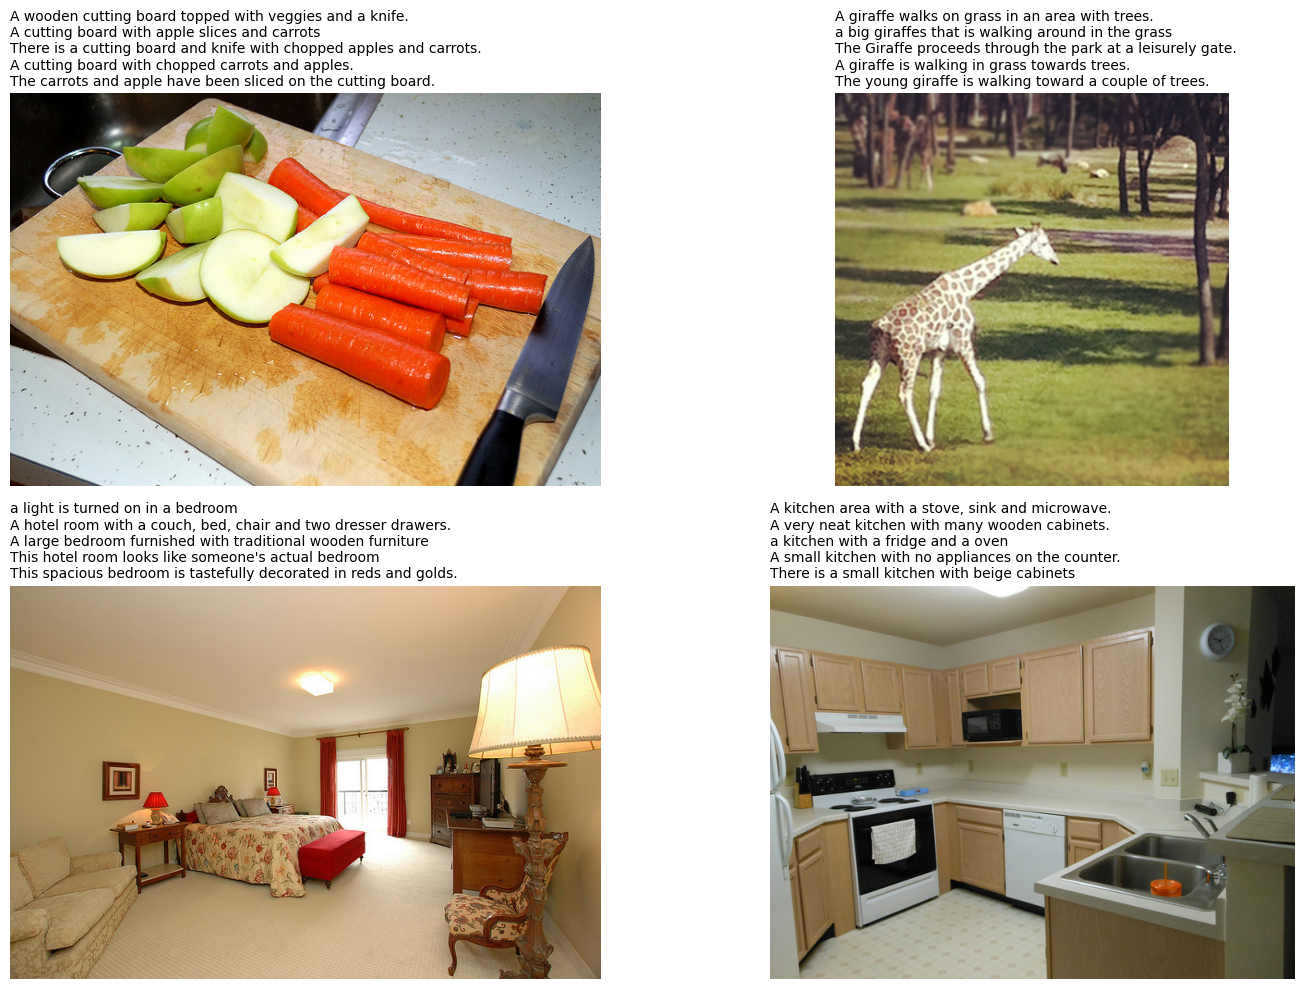

In [75]:
random.seed(1)
fig, axes = plt.subplots(2, 2, figsize=(15, 10))
axes = axes.flatten()
random_4_image_ids = random.sample(list(images_dict.keys()), 4)
for i, id in enumerate(random_4_image_ids):
    image = Image.open(os.path.join(path_images_train, images_dict[id]))
    axes[i].imshow(image)
    axes[i].axis('off')
    image_captions = annotation_dict[id]
    formatted_captions = "\n".join(image_captions)
    axes[i].set_title(formatted_captions, fontsize=10, loc='left')
plt.tight_layout()
plt.show()

In [76]:
print(image_names == set(images_dict.values())) # czy obrazy fizycznie zgadzają się z tymi w json

True


In [77]:
print(image_ids == annotated_images_ids) # czy obrazy i opisy się zgadzają

True


In [78]:
captions_count = [len(x) for x in annotation_dict.values()] # ile opisów na obraz
print(Counter(captions_count))

Counter({5: 117972, 6: 312, 7: 3})


In [79]:
image_infos = pd.DataFrame(train_json['images'])
image_infos['aspect_ratio'] = image_infos['width'] / image_infos['height']

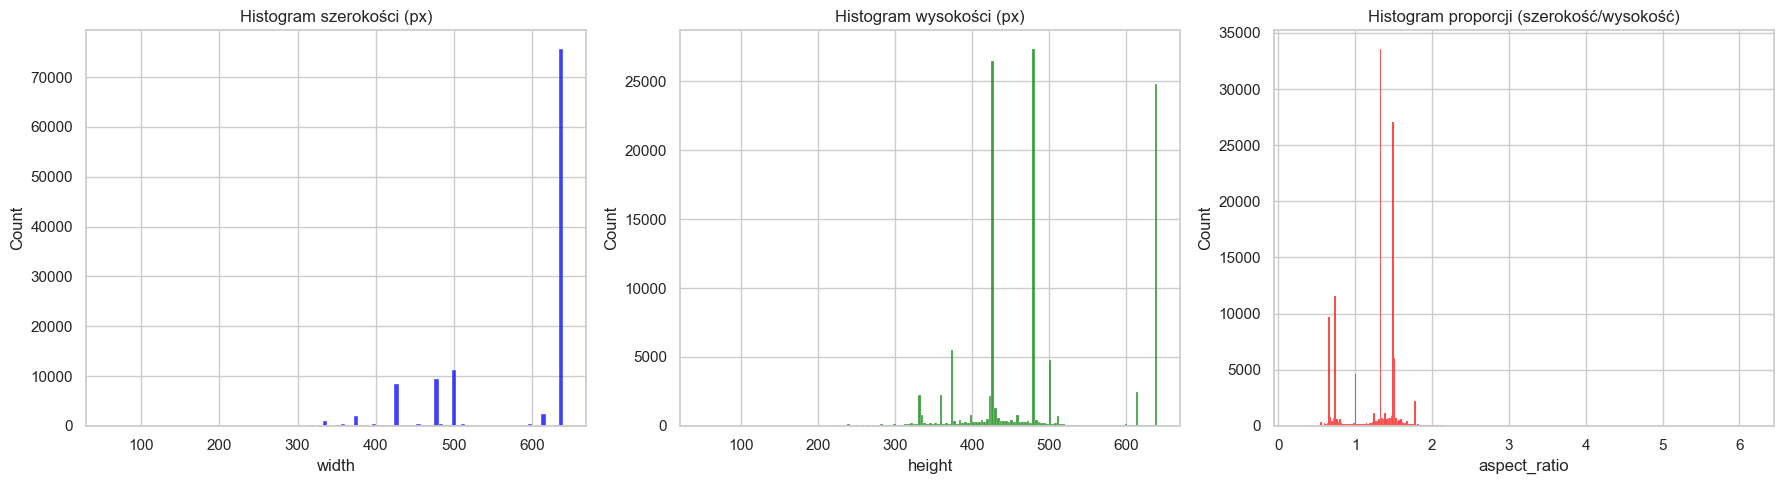

In [80]:
sns.set_theme(style='whitegrid')
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

# Hist. szerokości
sns.histplot(image_infos['width'], ax=axes[0], color='blue')
axes[0].set_title('Histogram szerokości (px)')

# Hist. wysokości
sns.histplot(image_infos['height'], ax=axes[1], color='green')
axes[1].set_title('Histogram wysokości (px)')

# Hist. proporcji
sns.histplot(image_infos['aspect_ratio'], ax=axes[2], color='red')
axes[2].set_title('Histogram proporcji (szerokość/wysokość)')

plt.tight_layout()
plt.show()

In [89]:
train_image_paths = [os.path.join(path_images_train, file) for file in os.listdir(path_images_train)]
sample_size = 5000
sample_train_image_paths = np.random.choice(train_image_paths, min(sample_size, len(train_image_paths)), replace=False)
image_mean_sum = np.zeros(3)
image_var_sum = np.zeros(3)
image_count = 0

In [90]:
for image_path in sample_train_image_paths:
    with Image.open(image_path).convert('RGB') as image:
        image = np.array(image) / 255.0
        image_mean = np.mean(image, axis=(0,1))
        image_var = np.var(image, axis=(0,1))

        image_mean_sum += image_mean
        image_var_sum += image_var
        image_count += 1
        
image_mean_final = image_mean_sum / image_count
image_var_final = image_var_sum / image_count

In [98]:
print(f"Średnia obrazków: \n\t{image_mean_final}")
print(f"Odchylenie standardowe obrazków: \n\t{np.sqrt(image_var_final)}")

Średnia obrazków: 
	[0.46829003 0.44547787 0.40591282]
Odchylenie standardowe obrazków: 
	[0.24903149 0.244436   0.24876897]


In [82]:
captions = [annot['caption'] for annot in train_json['annotations']]
caption_lengths = [len(caption.split()) for caption in captions]
caption_legths_df = pd.DataFrame(caption_lengths, columns=['count'])

In [83]:
word_stats = {
    'Średnia' : caption_legths_df['count'].mean(),
    'Mediana' : caption_legths_df['count'].median(),
    'Min' : caption_legths_df['count'].min(),
    'Max' : caption_legths_df['count'].max()
}
word_stats_text = '\n'.join([f"{title}: {value:.2f}" for title, value in word_stats.items()])

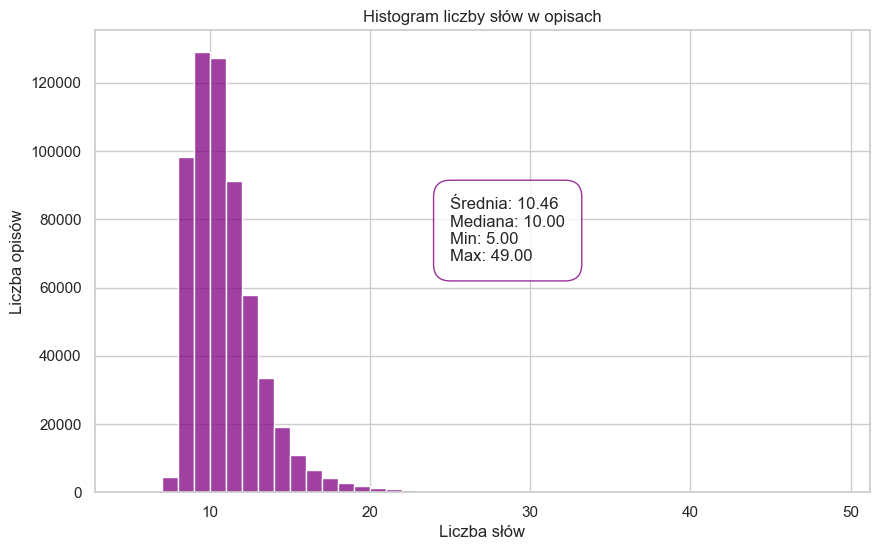

In [84]:
plt.figure(figsize=(10, 6))
sns.histplot(caption_legths_df['count'], bins=range(word_stats['Min'], word_stats['Max'] + 1), color='purple')
plt.title('Histogram liczby słów w opisach')
plt.xlabel('Liczba słów')
plt.ylabel('Liczba opisów')
plt.text(25, plt.gca().get_ylim()[1]*0.5, word_stats_text, fontsize=12, 
             bbox=dict(facecolor='white', alpha=0.8, edgecolor='purple', boxstyle='round,pad=1'))
plt.show()

In [ ]:
captions_lower = [caption.lower() for caption in captions]
captions_joined = " ".join(captions_lower)
words = re.findall(r"\b[a-z]{3,}\b", captions_joined) # słowa min. 3 litery

stopwords = ["i", "me", "my", "myself", "we", "our", "ours", "ourselves", "you", "your", "yours", "yourself", "yourselves", "he", "him", "his", 
             "himself", "she", "her", "hers", "herself", "it", "its", "itself", "they", "them", "their", "theirs", "themselves", "what", "which", 
             "who", "whom", "this", "that", "these", "those", "am", "is", "are", "was", "were", "be", "been", "being", "have", "has", "had", 
             "having", "do", "does", "did", "doing", "a", "an", "the", "and", "but", "if", "or", "because", "as", "until", "while", "of", "at", 
             "by", "for", "with", "about", "against", "between", "into", "through", "during", "before", "after", "above", "below", "to", "from", 
             "up", "down", "in", "out", "on", "off", "over", "under", "again", "further", "then", "once", "here", "there", "when", "where", "why", 
             "how", "all", "any", "both", "each", "few", "more", "most", "other", "some", "such", "no", "nor", "not", "only", "own", "same", "so", 
             "than", "too", "very", "s", "t", "can", "will", "just", "don", "should", "now"] # from NLTK
words_filtered = [word for word in words if word not in stopwords]

top_words = Counter(words_filtered).most_common(20)

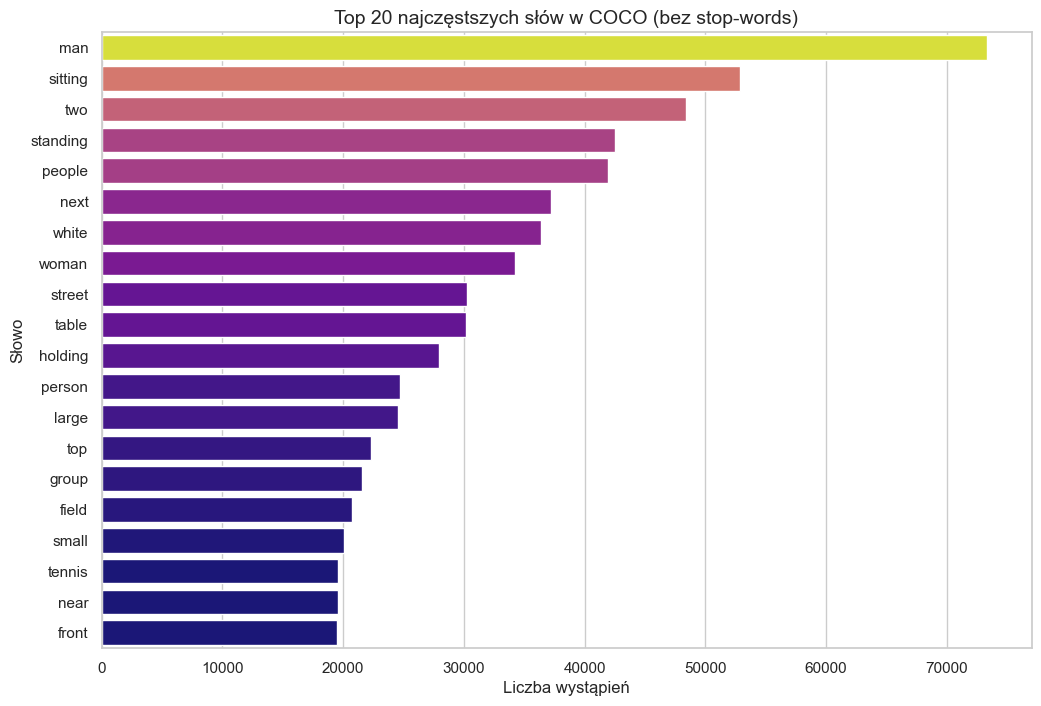

In [118]:
top_words_words = [top[0] for top in top_words]
top_words_count = [top[1] for top in top_words]
plt.figure(figsize=(12, 8))
sns.barplot(x=top_words_count, y=top_words_words, hue=top_words_count, palette='plasma', legend=False)
plt.title(f'Top 20 najczęstszych słów w COCO (bez stop-words)', fontsize=14)
plt.xlabel('Liczba wystąpień')
plt.ylabel('Słowo')
plt.show()